# Baseline

We build a PCA anomaly detection system to serve as a baseline for the subsequent autoencoder system.

In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, fbeta_score, confusion_matrix, classification_report
import numpy as np
import torch

from common.config import MNIST_RAW_PATH, FIGS_DIR
from common.utils import set_seed
from common.pca_detector import PCAAnomalyDetector
from common.plots import plot_anomaly_distribution, plot_fbeta_vs_threshold, plot_reconstructions, plot_performance_curves
from common.io import load_and_split_mnist
from common.finetuning import optimize_via_zooming_grid, optimize_fbeta_threshold

from typing import Tuple

SAVE_DIR = FIGS_DIR / "pca_baseline"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
SEED = 42
rs = set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:

train_normal, val_normal, val_anomaly, test_normal, test_anomaly = load_and_split_mnist(
    mnist_path=MNIST_RAW_PATH,
    val_anomaly_digit=8,
    test_anomaly_digit=4,
    random_seed=SEED
)

print("Train splits:")
print(f"train_normal: \tX={train_normal[0].shape}, y={train_normal[1].shape}")

print("\nValidation splits:")
print(f"val_normal:   \tX={val_normal[0].shape}, y={val_normal[1].shape}")
print(f"val_anomaly:  \tX={val_anomaly[0].shape}, y={val_anomaly[1].shape}")

print("\nTest splits:")
print(f"test_normal:  \tX={test_normal[0].shape}, y={test_normal[1].shape}")
print(f"test_anomaly: \tX={test_anomaly[0].shape}, y={test_anomaly[1].shape}")

Train splits:
train_normal: 	X=torch.Size([44304, 784]), y=torch.Size([44304, 10])

Validation splits:
val_normal:   	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
val_anomaly:  	X=torch.Size([974, 784]), y=torch.Size([974, 10])

Test splits:
test_normal:  	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
test_anomaly: 	X=torch.Size([982, 784]), y=torch.Size([982, 10])


## Hyperparameter tuning

We optimize the proportion of explained variance to be captured by the PCA detector (`n_components`). Optimization is performed via a zooming grid search to find the best parameter efficiently. Precision-Recall (PR) AUC is selected as the maximization objective. PR AUC was preferred over ROC AUC because the dataset is highly imbalanced; under heavy class imbalance, ROC AUC can provide an overly optimistic view of performance, whereas PR AUC is highly sensitive to false positives.

In [4]:
def optimize_pca(pca_cls, train_X, test_normal_X, test_anomaly_X, n_components_min, n_components_max, random_state=None, **kwargs):

    def pca_score_callback(n_components: float) -> Tuple[np.ndarray, np.ndarray]:
        pca = pca_cls(n_components=n_components, random_state=random_state)
        pca.fit(train_X)

        normal_scores = pca.score_samples(test_normal_X).cpu().numpy()
        anomaly_scores = pca.score_samples(test_anomaly_X).cpu().numpy()
        return normal_scores, anomaly_scores

    return optimize_via_zooming_grid(
        score_fn=pca_score_callback,
        param_min=n_components_min,
        param_max=n_components_max,
        param_name="n_comp",
        **kwargs
    )

best_n, best_auc = optimize_pca(
    pca_cls=PCAAnomalyDetector,
    train_X=train_normal[0],
    test_normal_X=val_normal[0],
    test_anomaly_X=val_anomaly[0],
    n_components_min=0.6,
    n_components_max=0.8,
    random_state=SEED,
    size=4,
    depth=5,
    verbose=True
)

print(f"\nBest n_components: {best_n:.6f}")
print(f"Best PR AUC: {best_auc:.6f}")


Zoom Step 1/5 Interval: [0.6000, 0.8000]
n_comp     | PR AUC    
0.6000     | 0.4460    
0.6667     | 0.4699    
0.7333     | 0.4486    
0.8000     | 0.4409    

Zoom Step 2/5 Interval: [0.6333, 0.7000]
n_comp     | PR AUC    
0.6333     | 0.4763    
0.6556     | 0.4606    
0.6778     | 0.4769    
0.7000     | 0.4725    

Zoom Step 3/5 Interval: [0.6667, 0.6889]
n_comp     | PR AUC    
0.6667     | 0.4699    
0.6741     | 0.4769    
0.6815     | 0.4836    
0.6889     | 0.4916    

Zoom Step 4/5 Interval: [0.6852, 0.6926]
n_comp     | PR AUC    
0.6852     | 0.4836    
0.6877     | 0.4836    
0.6901     | 0.4916    
0.6926     | 0.4916    

Zoom Step 5/5 Interval: [0.6889, 0.6914]
n_comp     | PR AUC    
0.6889     | 0.4916    
0.6897     | 0.4916    
0.6905     | 0.4916    
0.6914     | 0.4916    

Best n_components: 0.688889
Best PR AUC: 0.491551


In [5]:
pca = PCAAnomalyDetector(n_components=best_n, random_state=SEED)
pca.fit(train_normal[0])

print(f"Number of components: {pca.n_components_}")

Number of components: 24


## Threshold calibration

Next, we separately optimize the classification threshold using the $F_\beta$ score (specifically $F_2$). The $F_2$ score was chosen to build a sensitive threshold that prioritizes recall over precision, ensuring fewer anomalies are missed. Threshold optimization is kept separate from the capacity tuning (`n_components`) to prevent overfitting on the anomalous validation subset, as PR AUC is a more robust, threshold-agnostic metric than a single $F_\beta$ score value.

In [6]:
normal_scores = pca.score_samples(val_normal[0]).cpu().numpy()
anomaly_scores = pca.score_samples(val_anomaly[0]).cpu().numpy()

beta = 2.0
best_threshold, best_results = optimize_fbeta_threshold(
    val_normal_scores=normal_scores,
    val_anomaly_scores=anomaly_scores,
    beta = beta
)

print(f"Best Threshold: {best_threshold:.6f}")
print(f"Best F2-score: {best_results['fbeta']:.4f}")

Best Threshold: 0.021685
Best F2-score: 0.6933


Best threshold for F2.0-score: 0.021685
Accuracy:  0.6781
Precision: 0.3662
Recall:    0.8912
F2.0 score:  0.6926

Confusion matrix:
[[2520 1502]
 [ 106  868]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9596    0.6266    0.7581      4022
         1.0     0.3662    0.8912    0.5191       974

    accuracy                         0.6781      4996
   macro avg     0.6629    0.7589    0.6386      4996
weighted avg     0.8439    0.6781    0.7115      4996



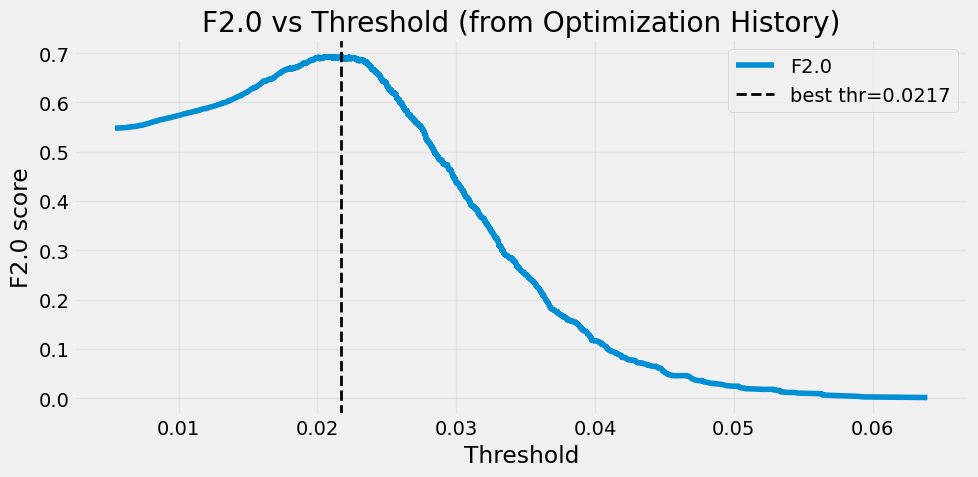

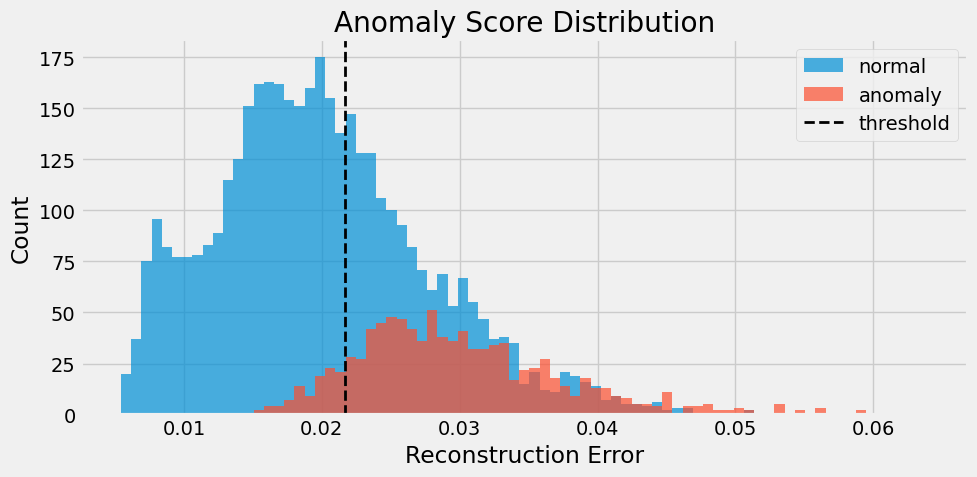

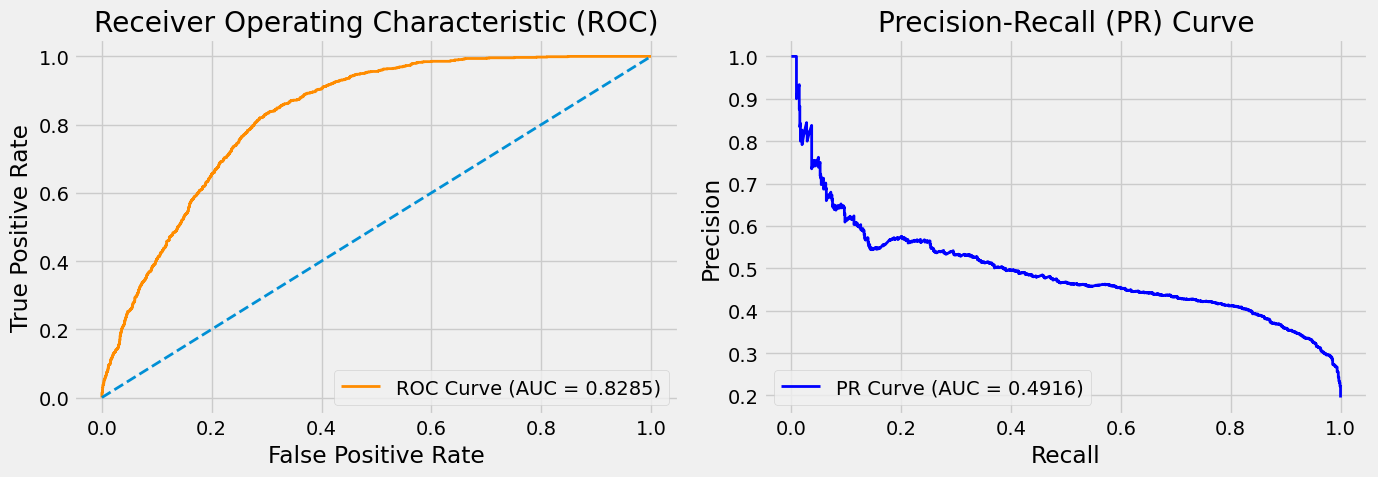

In [7]:
y_true = best_results['y_true']
y_scores = best_results['y_scores']
thresholds = best_results['thresholds']
fbeta_vals = best_results['fbeta_vals']
y_pred = (y_scores > best_threshold).astype(int)

# Print metrics
print(f'Best threshold for F{beta}-score: {best_threshold:.6f}')
print(f'Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
print(f'Precision: {precision_score(y_true, y_pred):.4f}')
print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
print(f'F{beta} score:  {fbeta_score(y_true, y_pred, beta=beta):.4f}')
print('\nConfusion matrix:')
print(confusion_matrix(y_true, y_pred))
print('\nClassification report:')
print(classification_report(y_true, y_pred, digits=4))

# Plot Fbeta curve
plot_fbeta_vs_threshold(thresholds, fbeta_vals, best_threshold, beta, save_path=SAVE_DIR / f"pca_f{beta}_vs_threshold.png")

# Plot anomaly distribution
plot_anomaly_distribution(normal_scores, anomaly_scores, best_threshold, save_path=SAVE_DIR / "pca_anomaly_score_distribution.png")

plot_performance_curves(y_true, y_scores, save_path=SAVE_DIR / "pca_performance_curves.png")

We show a small subset of reconstructed samples for comparison with original input.

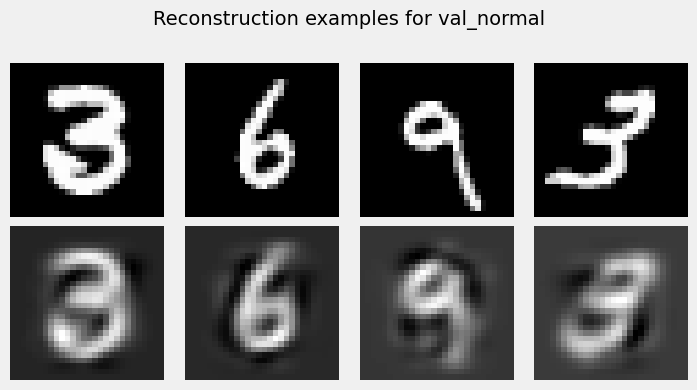

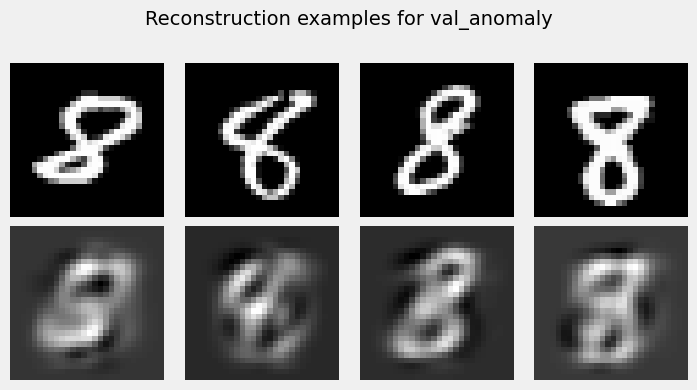

In [9]:
val_normal_recon = pca.reconstruct(val_normal[0][:4]).detach().cpu().numpy()
val_anomaly_recon = pca.reconstruct(val_anomaly[0][:4]).detach().cpu().numpy()

plot_reconstructions(val_normal[0], val_normal_recon, 'Reconstruction examples for val_normal', save_path=SAVE_DIR / 'pca_rec_val_normal.png')

plot_reconstructions(val_anomaly[0], val_anomaly_recon, 'Reconstruction examples for val_anomaly', save_path=SAVE_DIR / 'pca_rec_val_anomaly.png')

We obtained a surprisingly well-performing linear anomaly detection system.

Since PCA relies purely on linear combinations of pixels, it struggles with spatial dependencies, which is the reason why its precision is low. As a consequence of this, and the fact that the threshold was optimized to be more sensitive to anomalies, the current solution suffers greatly from false positives.

The Autoencoder system is expected to leverage non-linearity to solve these problems, separating anomalies from normal data much better.